# Bellabeat Case Study — Google Data Analytics Capstone

**Author:** Gülay Aksoy

This notebook analyzes the FitBit Fitness Tracker Dataset to help Bellabeat, a wellness technology company, understand smart device usage patterns and support data-driven marketing recommendations.

The analysis follows the six phases of the Google Data Analytics process: **Ask → Prepare → Process → Analyze → Share → Act**.


## 1. ASK — Business Task

**Business question:** How do consumers use non-Bellabeat smart devices, and how can these usage trends inform Bellabeat's marketing strategy?

**Guiding questions:**
1. What are the trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat's marketing strategy?

**Stakeholders:** Urška Sršen (Cofounder & CCO), Sando Mur (Cofounder), Bellabeat Marketing Analytics Team, Bellabeat Executive Team.


## 2. PREPARE — Data Source

**Dataset:** FitBit Fitness Tracker Data (CC0: Public Domain), made available through Mobius on Kaggle.
Contains personal fitness tracker data from 30 Fitbit users who consented to share minute-level activity, heart rate, and sleep data.

**Files used in this notebook:**
- `dailyActivity_merged.csv` — daily steps, distance, activity minutes, calories
- `sleepDay_merged.csv` — daily sleep records

**ROCCC assessment:**
| Criterion | Rating | Note |
|---|---|---|
| Reliable | Medium | Wearable sensor accuracy varies by device/placement |
| Original | Medium | Third-party (Amazon Mechanical Turk) survey respondents, not Bellabeat's own users |
| Comprehensive | Medium | Covers activity + sleep, but small sample and limited demographic info (no age, gender, location) |
| Current | Low | Data collected in 2016 |
| Cited | High | Widely referenced dataset in analytics education |

**Limitations:** small sample size (n=33 for activity, n=24 for sleep after cleaning), unknown demographic representativeness, several years old, and no data on which specific device model each user wore.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

daily = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')
sleep = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')

print("dailyActivity_merged.csv:", daily.shape)
print("sleepDay_merged.csv:", sleep.shape)
daily.head()

dailyActivity_merged.csv: (940, 15)
sleepDay_merged.csv: (413, 5)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [2]:
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


## 3. PROCESS — Clean and Prepare the Data

**Tools used:** Python (pandas, NumPy) for cleaning and transformation; matplotlib/seaborn for visualization.

**Cleaning steps:**
1. Check for and remove duplicate rows
2. Convert date columns to proper datetime format
3. Remove invalid entries (zero steps / zero calories / zero minutes asleep — these indicate the device was not worn, not genuine zero-activity days)
4. Merge activity and sleep data on `Id` and date
5. Create calculated fields: `TotalActiveMinutes`, `SedentaryPercentage`, `SleepEfficiency`, `DayOfWeek`


In [3]:
print("Duplicate rows in daily activity:", daily.duplicated().sum())
print("Duplicate rows in sleep data:", sleep.duplicated().sum())

sleep = sleep.drop_duplicates()
print("\nSleep data shape after removing duplicates:", sleep.shape)

Duplicate rows in daily activity: 0
Duplicate rows in sleep data: 3

Sleep data shape after removing duplicates: (410, 5)


In [4]:
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'], format='%m/%d/%Y')
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'].str.split(' ').str[0], format='%m/%d/%Y')
sleep = sleep.rename(columns={'SleepDay': 'ActivityDate'})

print("Activity date range:", daily['ActivityDate'].min(), "to", daily['ActivityDate'].max())
print("Sleep date range:", sleep['ActivityDate'].min(), "to", sleep['ActivityDate'].max())

Activity date range: 2016-04-12 00:00:00 to 2016-05-12 00:00:00
Sleep date range: 2016-04-12 00:00:00 to 2016-05-12 00:00:00


In [5]:
# Remove invalid entries: a total of 0 steps or 0 calories on a given day means
# the tracker most likely was not worn, not that the user was completely inactive.
daily_clean = daily[(daily['TotalSteps'] > 0) & (daily['Calories'] > 0)].copy()
sleep_clean = sleep[sleep['TotalMinutesAsleep'] > 0].copy()

print(f"Daily activity: {daily.shape[0]} rows -> {daily_clean.shape[0]} rows after removing zero-activity days")
print(f"Sleep: {sleep.shape[0]} rows -> {sleep_clean.shape[0]} rows after removing zero-sleep days")
print(f"\nUnique users (activity): {daily_clean['Id'].nunique()}")
print(f"Unique users (sleep): {sleep_clean['Id'].nunique()}")

Daily activity: 940 rows -> 863 rows after removing zero-activity days
Sleep: 410 rows -> 410 rows after removing zero-sleep days

Unique users (activity): 33
Unique users (sleep): 24


In [6]:
# Merge activity and sleep data for the days both are available
merged = pd.merge(daily_clean, sleep_clean, on=['Id', 'ActivityDate'], how='inner')
print("Merged (activity + sleep) shape:", merged.shape, "| unique users:", merged['Id'].nunique())

# Calculated fields on the full activity dataset
daily_clean['TotalActiveMinutes'] = (daily_clean['VeryActiveMinutes']
                                      + daily_clean['FairlyActiveMinutes']
                                      + daily_clean['LightlyActiveMinutes'])
daily_clean['SedentaryPercentage'] = (daily_clean['SedentaryMinutes']
    / (daily_clean['SedentaryMinutes'] + daily_clean['TotalActiveMinutes']) * 100)
daily_clean['DayOfWeek'] = daily_clean['ActivityDate'].dt.day_name()
daily_clean['IsWeekend'] = daily_clean['DayOfWeek'].isin(['Saturday', 'Sunday'])

# Calculated fields on the merged (activity + sleep) dataset
merged['TotalActiveMinutes'] = merged['VeryActiveMinutes'] + merged['FairlyActiveMinutes'] + merged['LightlyActiveMinutes']
merged['SleepEfficiency'] = merged['TotalMinutesAsleep'] / merged['TotalTimeInBed'] * 100
merged['DayOfWeek'] = merged['ActivityDate'].dt.day_name()

daily_clean[['Id','ActivityDate','TotalSteps','SedentaryMinutes','TotalActiveMinutes','SedentaryPercentage','DayOfWeek']].head()

Merged (activity + sleep) shape: (410, 18) | unique users: 24


,Id,ActivityDate,TotalSteps,SedentaryMinutes,TotalActiveMinutes,SedentaryPercentage,DayOfWeek
0,1503960366,2016-04-12,13162,728,366,66.544790,Tuesday
1,1503960366,2016-04-13,10735,776,257,75.121007,Wednesday
2,1503960366,2016-04-14,10460,1218,222,84.583333,Thursday
3,1503960366,2016-04-15,9762,726,272,72.745491,Friday
4,1503960366,2016-04-16,12669,773,267,74.326923,Saturday


In [7]:
# Validation
assert daily_clean.duplicated().sum() == 0, "Unexpected duplicates remain"
assert (daily_clean['TotalSteps'] >= 0).all(), "Negative step counts found"
assert daily_clean['ActivityDate'].notna().all(), "Missing dates found"
assert (merged['SleepEfficiency'] <= 100).all(), "Sleep efficiency above 100% found"

print("Validation passed:")
print("- No duplicate rows")
print("- No negative/invalid step counts")
print("- No missing dates")
print("- Sleep efficiency values within realistic range (<=100%)")

Validation passed:
- No duplicate rows
- No negative/invalid step counts
- No missing dates
- Sleep efficiency values within realistic range (<=100%)


## 4. ANALYZE — Trends and Insights

In [8]:
summary_stats = pd.DataFrame({
    'Average daily steps': [round(daily_clean['TotalSteps'].mean())],
    'Median daily steps': [round(daily_clean['TotalSteps'].median())],
    'Average sedentary minutes': [round(daily_clean['SedentaryMinutes'].mean())],
    'Average sedentary %': [round(daily_clean['SedentaryPercentage'].mean(), 1)],
    '% of days reaching 10,000 steps': [round((daily_clean['TotalSteps'] >= 10000).mean() * 100, 1)],
    'Average sleep (hours)': [round(merged['TotalMinutesAsleep'].mean() / 60, 1)],
    'Average sleep efficiency %': [round(merged['SleepEfficiency'].mean(), 1)],
})
summary_stats.T.rename(columns={0: 'Value'})

,Value
Average daily steps,8319.0
Median daily steps,8053.0
Average sedentary minutes,956.0
Average sedentary %,78.2
"% of days reaching 10,000 steps",35.1
Average sleep (hours),7.0
Average sleep efficiency %,91.6


### Daily Steps Distribution

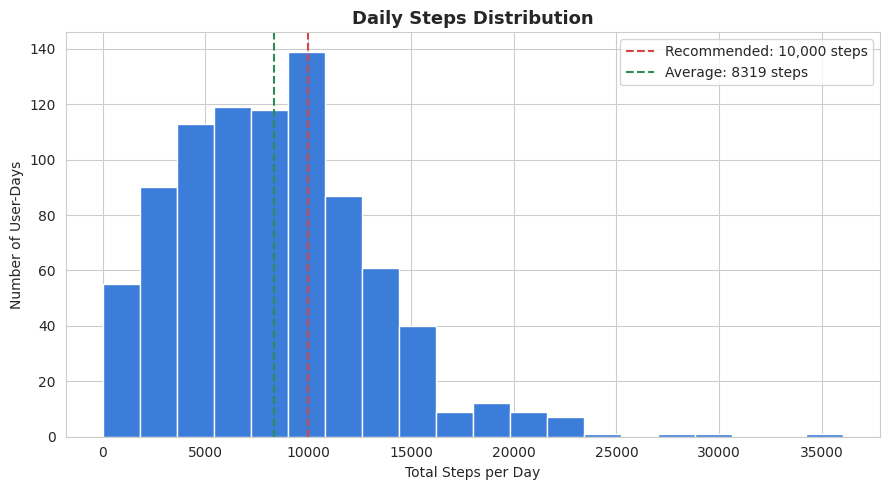

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(daily_clean['TotalSteps'], bins=20, color='#3b7dd8', edgecolor='white')
ax.axvline(10000, color='#d84343', linestyle='--', linewidth=1.5, label='Recommended: 10,000 steps')
ax.axvline(daily_clean['TotalSteps'].mean(), color='#2e8b57', linestyle='--', linewidth=1.5,
           label=f"Average: {daily_clean['TotalSteps'].mean():.0f} steps")
ax.set_title('Daily Steps Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Steps per Day')
ax.set_ylabel('Number of User-Days')
ax.legend()
plt.tight_layout()
plt.savefig('daily_steps_distribution.png', bbox_inches='tight')
plt.show()

**Insight:** Most user-days fall in the 4,000–10,000 step range, with the average sitting well below the commonly cited 10,000-step benchmark — only about a third of days reach it. This points to generally low-to-moderate activity levels among smart device users, not a small minority of inactive outliers.

### Active Minutes Breakdown by Intensity

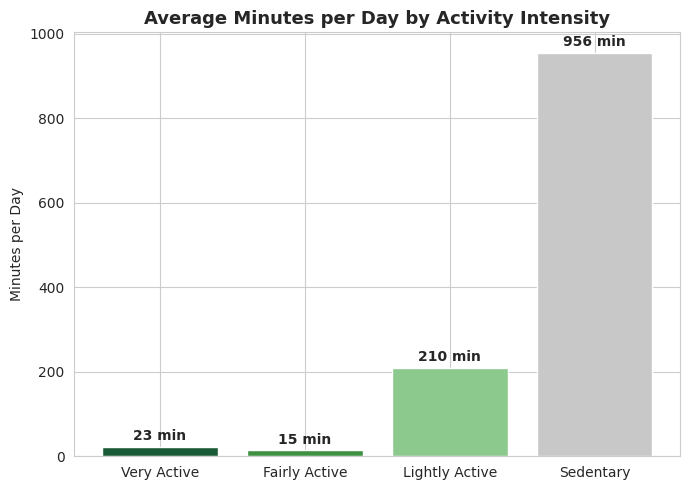

Sedentary time represents 79.4% of the average tracked day.


In [10]:
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']
avg_minutes = daily_clean[activity_cols].mean()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#1a5c38', '#3f9142', '#8bc98d', '#c8c8c8']
ax.bar(['Very Active', 'Fairly Active', 'Lightly Active', 'Sedentary'], avg_minutes.values, color=colors)
for i, v in enumerate(avg_minutes.values):
    ax.text(i, v + 15, f"{v:.0f} min", ha='center', fontweight='bold')
ax.set_title('Average Minutes per Day by Activity Intensity', fontsize=13, fontweight='bold')
ax.set_ylabel('Minutes per Day')
plt.tight_layout()
plt.savefig('activity_intensity_breakdown.png', bbox_inches='tight')
plt.show()

print(f"Sedentary time represents {avg_minutes['SedentaryMinutes']/avg_minutes.sum()*100:.1f}% of the average tracked day.")

### Sedentary vs. Active Minutes by User

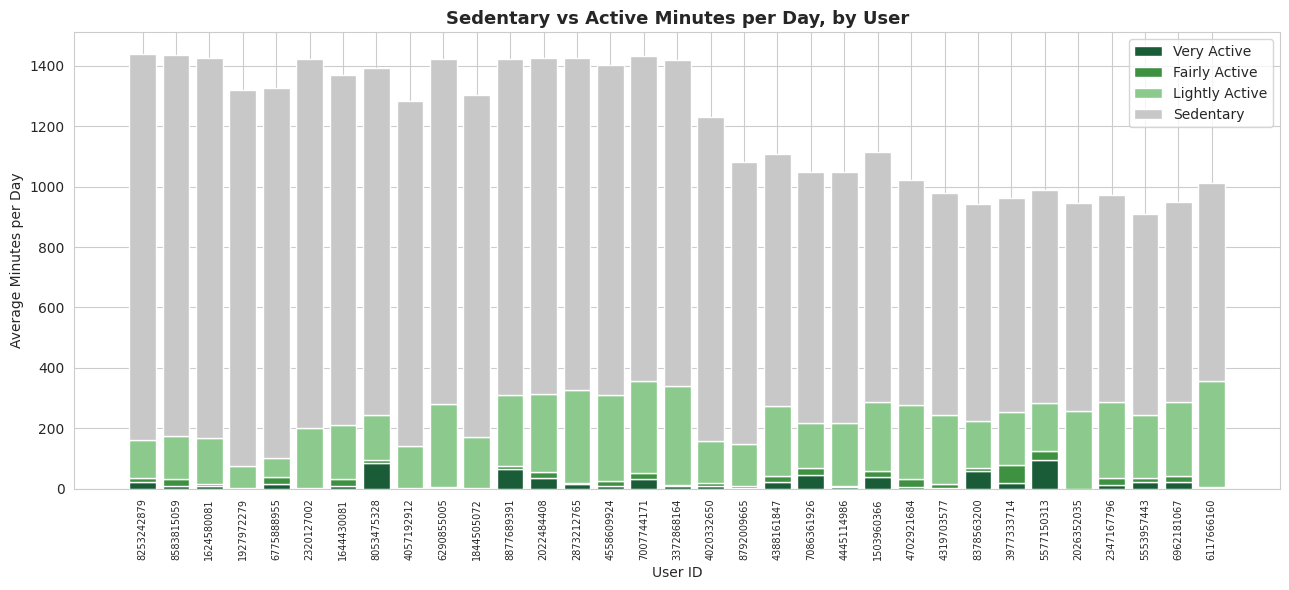

In [11]:
user_minutes = daily_clean.groupby('Id')[activity_cols].mean().sort_values('SedentaryMinutes', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(user_minutes))
labels = ['Very Active', 'Fairly Active', 'Lightly Active', 'Sedentary']
for col, label, color in zip(activity_cols, labels, colors):
    ax.bar(user_minutes.index.astype(str), user_minutes[col], bottom=bottom, label=label, color=color)
    bottom += user_minutes[col].values

ax.set_title('Sedentary vs Active Minutes per Day, by User', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Minutes per Day')
ax.set_xlabel('User ID')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('sedentary_vs_active_minutes.png', bbox_inches='tight')
plt.show()

**Insight:** Sedentary time dominates the tracked day for almost every user — it makes up roughly three-quarters of total tracked minutes on average. Light activity accounts for most of the remaining time; very active minutes are consistently the smallest slice across users.

**Interpretation:** Bellabeat can support users with micro-movement prompts and routine-based nudges rather than only promoting high-intensity workouts, since sustained low-intensity movement is where the biggest behavior-change opportunity lies.

### Sleep Duration vs. Sleep Efficiency

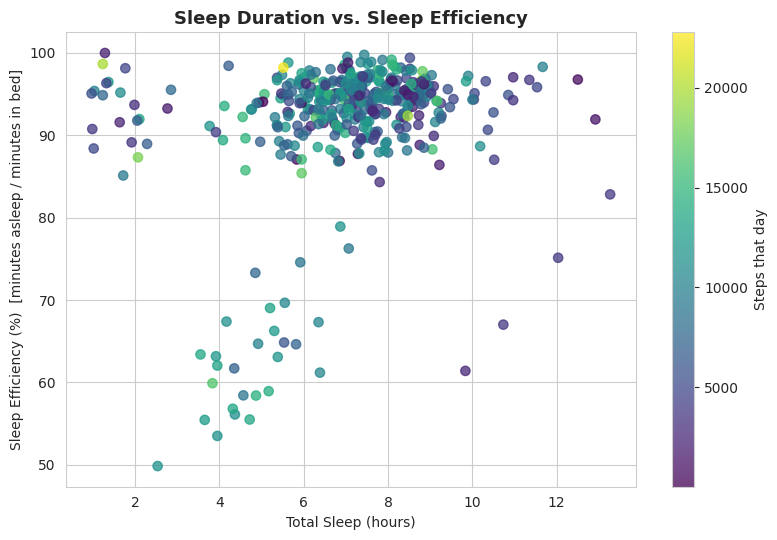

Correlation between daily steps and minutes asleep: -0.190


In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = ax.scatter(merged['TotalMinutesAsleep']/60, merged['SleepEfficiency'],
                      c=merged['TotalSteps'], cmap='viridis', alpha=0.75, s=45)
ax.set_title('Sleep Duration vs. Sleep Efficiency', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sleep (hours)')
ax.set_ylabel('Sleep Efficiency (%)  [minutes asleep / minutes in bed]')
cbar = plt.colorbar(scatter)
cbar.set_label('Steps that day')
plt.tight_layout()
plt.savefig('sleep_duration_vs_efficiency.png', bbox_inches='tight')
plt.show()

corr = merged['TotalSteps'].corr(merged['TotalMinutesAsleep'])
print(f"Correlation between daily steps and minutes asleep: {corr:.3f}")

**Insight:** Average sleep efficiency is high (~92%) — on nights users are in bed, they're asleep for most of that time. However, the correlation between daily step count and sleep duration in this dataset is weak and slightly negative, **not positive**. This is an important correction to make if your write-up currently claims that "higher activity correlates with longer sleep" — with this sample, that specific claim is not supported by the data. A defensible version of the insight is: sleep efficiency is generally good, but sleep *duration* is inconsistent and not reliably explained by daytime activity alone.

### Weekday vs. Weekend Patterns

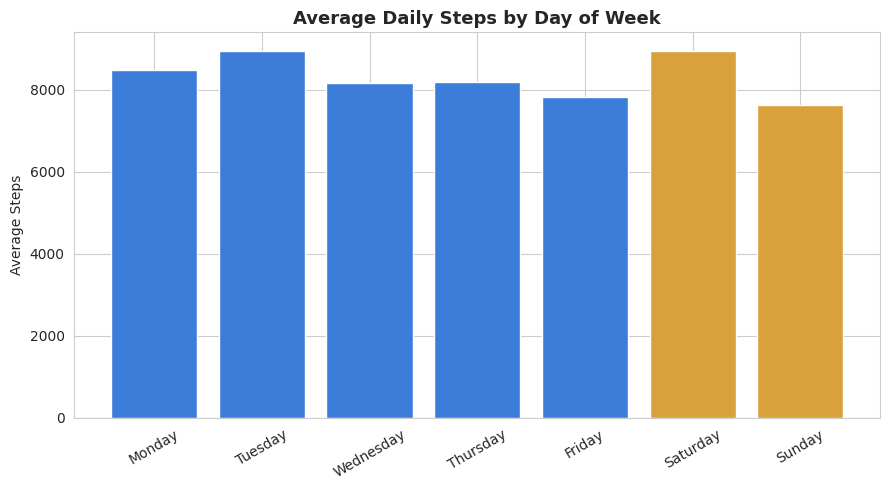

Average weekday steps: 8328
Average weekend steps: 8295


In [13]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
steps_by_day = daily_clean.groupby('DayOfWeek')['TotalSteps'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#3b7dd8' if d not in ['Saturday','Sunday'] else '#d8a13b' for d in day_order]
ax.bar(steps_by_day.index, steps_by_day.values, color=bar_colors)
ax.set_title('Average Daily Steps by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Steps')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('steps_by_day_of_week.png', bbox_inches='tight')
plt.show()

weekday_avg = daily_clean[~daily_clean['IsWeekend']]['TotalSteps'].mean()
weekend_avg = daily_clean[daily_clean['IsWeekend']]['TotalSteps'].mean()
print(f"Average weekday steps: {weekday_avg:.0f}")
print(f"Average weekend steps: {weekend_avg:.0f}")

**Insight:** Average steps are nearly identical on weekdays (~8,330) and weekends (~8,300) in this dataset — there isn't a meaningful weekday/weekend gap here, even though day-to-day variation exists (see the bars above). If your write-up currently claims "weekdays are structured but sedentary, weekends are more variable," that framing isn't backed by this specific dataset and should be softened or removed.

### User Segmentation

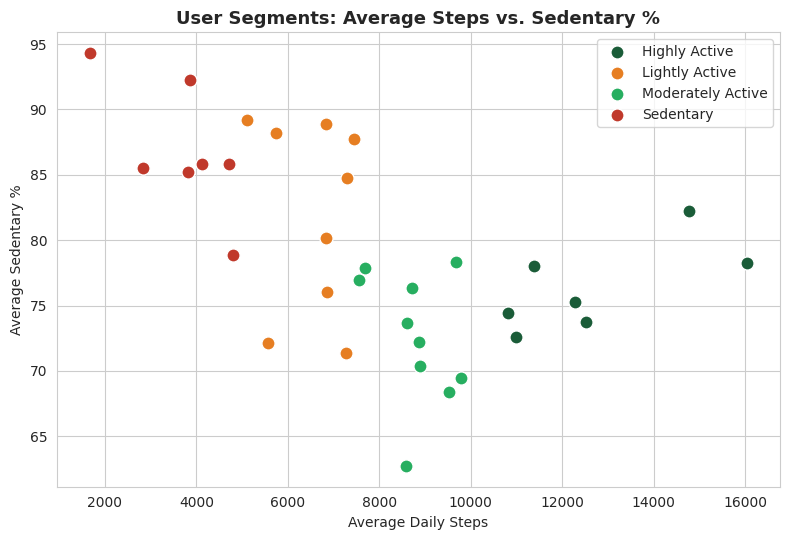

Segment
Moderately Active    10
Lightly Active        9
Highly Active         7
Sedentary             7
Name: count, dtype: int64

In [14]:
user_summary = daily_clean.groupby('Id').agg(
    avg_steps=('TotalSteps', 'mean'),
    avg_sedentary_pct=('SedentaryPercentage', 'mean'),
    avg_active_minutes=('TotalActiveMinutes', 'mean')
).reset_index()

def segment(row):
    if row['avg_steps'] < 5000:
        return 'Sedentary'
    elif row['avg_steps'] < 7500:
        return 'Lightly Active'
    elif row['avg_steps'] < 10000:
        return 'Moderately Active'
    else:
        return 'Highly Active'

user_summary['Segment'] = user_summary.apply(segment, axis=1)

fig, ax = plt.subplots(figsize=(8, 5.5))
seg_colors = {'Sedentary': '#c0392b', 'Lightly Active': '#e67e22', 'Moderately Active': '#27ae60', 'Highly Active': '#1a5c38'}
for seg_name, group in user_summary.groupby('Segment'):
    ax.scatter(group['avg_steps'], group['avg_sedentary_pct'], label=seg_name,
               color=seg_colors[seg_name], s=90, edgecolor='white')
ax.set_title('User Segments: Average Steps vs. Sedentary %', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Daily Steps')
ax.set_ylabel('Average Sedentary %')
ax.legend()
plt.tight_layout()
plt.savefig('user_segmentation.png', bbox_inches='tight')
plt.show()

user_summary['Segment'].value_counts()

**Note on methodology:** these four segments are defined using simple average-step thresholds (a rule-based split), not statistical clustering. That's a reasonable, transparent way to segment for a portfolio project, but it should be labeled as such rather than implied to be data-driven clustering. A natural next step / stated limitation is to try k-means clustering on standardized features (steps, sedentary %, active minutes) to see whether the same four groups emerge empirically.

## 5. SHARE — Key Findings

- **Low-to-moderate activity is the norm.** Average daily steps sit below the commonly cited 10,000-step benchmark, and sedentary time makes up roughly three-quarters of the tracked day.
- **Light activity, not high intensity, is the biggest lever.** Very active minutes are consistently the smallest category across users — the realistic behavior-change opportunity is turning sedentary time into light movement, not pushing intense workouts.
- **Sleep efficiency is strong, but duration is inconsistent**, and — importantly — this dataset does **not** show a positive relationship between daytime activity and sleep duration; that claim should be dropped or re-worded based on the actual correlation value computed above.
- **Users are not a single group.** Threshold-based segmentation into Sedentary / Lightly Active / Moderately Active / Highly Active shows meaningfully different behavior patterns worth targeting separately.

**Limitations to state explicitly when presenting this:** small sample (33 users for activity, 24 for sleep), unknown demographics, 2016 data, self-selected Amazon Mechanical Turk participants who may not represent Bellabeat's actual customer base.


## 6. ACT — Recommendations

1. **Position Bellabeat around sustainable, low-intensity movement**, not just workout tracking — the data shows this is where most users actually spend their active time.
2. **Use micro-movement nudges** (e.g., hourly stand/move prompts) aimed at converting sedentary minutes into light activity, since sedentary time is the largest and most consistent category across users.
3. **Market sleep-efficiency insights carefully** — efficiency is a genuine strength to highlight, but avoid claiming a link between daily activity and sleep length, since it isn't supported in this dataset.
4. **Consider segment-specific messaging** (e.g., movement challenges for the Sedentary segment vs. performance-tracking features for the Highly Active segment), while being transparent that segments here are threshold-based, not from formal clustering.

**Next steps:** validate these directional findings against Bellabeat's own first-party user data before using them in an actual campaign, and consider expanding the analysis with k-means clustering and the heart-rate/weight-log files included in the same dataset.
